In [ ]:
!https://github.com/samylesousa/curso-visao-computacional.git

%cd curso-visao-computacional/semana_1/equalizacao

# Equalização de histograma
O histograma de uma imagem é um gráfico das frequências dos níveis de intensidade dos pixels, ou seja cada bin do histograma apresenta a quantidade de vezes que um nível de intensidade aparece em relação a todos os pixels da imagem.

O nível de intensidade de um pixel varia de 0 a 255, sendo que **imagens em tom de cinza são representadas apenas por um histograma** enquanto **imagens coloridas são representadas por três histogramas** —  pois se baseiam no sistema RGB.



(0.0, 256.0)

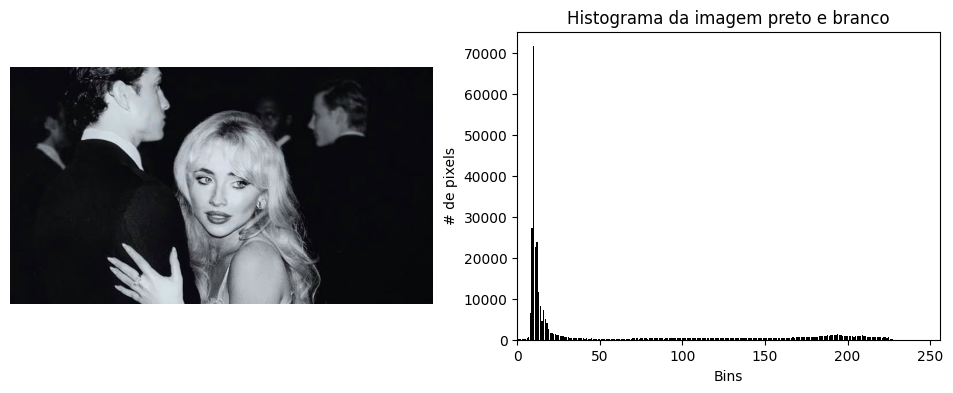

In [86]:
import cv2
from matplotlib import pyplot as plt

#imagem
img_black_white = cv2.imread('imagens/imagem1.jpg')

#convertendo a imagem para tons de cinza
gray_img = cv2.cvtColor(img_black_white, cv2.COLOR_BGR2GRAY)

#calculando o histograma
hist_black_white = cv2.calcHist([gray_img], [0], None, [256], [0, 256])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

#plotando a imagem em preto e branco
ax1.axis("off")
ax1.imshow(img_black_white)

#plotando o histograma
ax2.set_title("Histograma da imagem preto e branco")
ax2.set_xlabel("Bins")
ax2.set_ylabel("# de pixels")
ax2.bar(range(256), hist_black_white.flatten(), color='black')
ax2.set_xlim([0, 256])


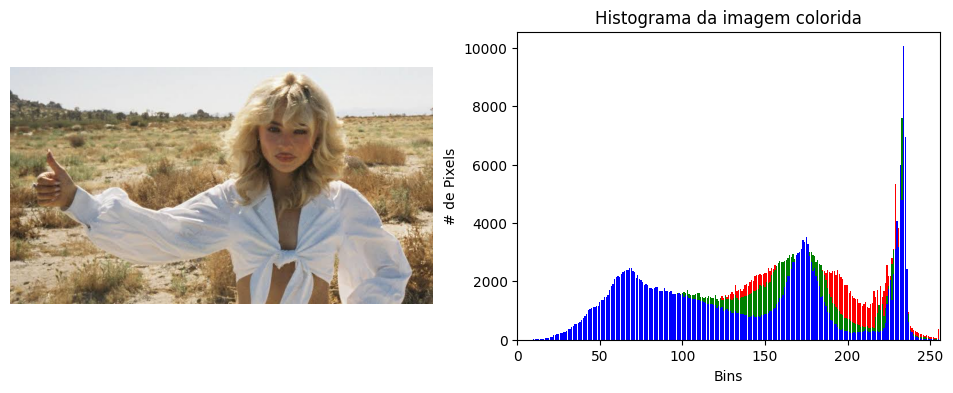

In [87]:
#trabalhando com a imagem colorida
img_color = cv2.imread('imagens/imagem2.jpg')

colors = ('r','g','b')
img_color_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)

#separando os canais da imagem
#como eu converti para rgb a ordem será red, green, blue
chans = cv2.split(img_color_rgb)

fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(12, 4))
#plotando a imagem colorida
ax3.axis("off")
ax3.imshow(img_color_rgb)

#plotando o histograma da imagem colorida
ax4.set_title("Histograma da imagem colorida")
ax4.set_xlabel("Bins")
ax4.set_ylabel("# de Pixels")

#loop para os canais da imagens
for (chan, color) in zip(chans, colors):
  hist = cv2.calcHist([chan], [0], None, [256], [0, 256])
  ax4.bar(range(256), hist.flatten(), color=color)
  ax4.set_xlim([0, 256])


## Visualização utilizando histogramas 2d

**O que são histogramas 2d?** São versões bidimensionais onde a frequência de combinações de dois conjuntos de valores é exibida. Eles costumam ser usados para visualizar a relação entre duas variáveis e entender como uma pode afetar a outra.

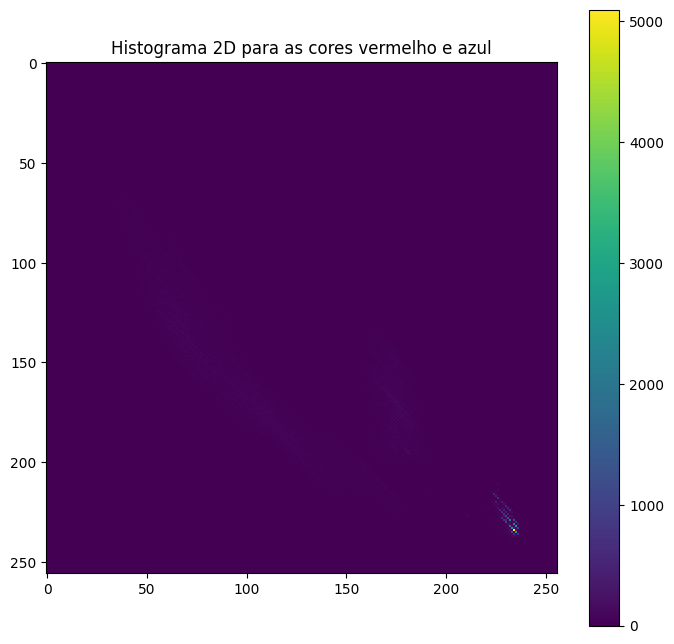

In [88]:
fig3 = plt.figure(figsize=(28, 8))
ax = fig3.add_subplot(131)

#calculo do histograma para os canais red e blue da imagem colorida
hist2d = cv2.calcHist([chans[0], chans[2]], [0, 1], None, [256, 256], [0, 256, 0, 256])
p = ax.imshow(hist2d, interpolation="nearest")
ax.set_title("Histograma 2D para as cores vermelho e azul")
plt.colorbar(p)
plt.show()

*Interpretação do histograma*





A maior parte do gráfico é roxo, ou seja zero pixels, pois a combinação de vermelho e azul quase não existe na imagem. Porém, no ponto brilhante no canto inferior direito (entre 230, 230) existe uma concentração de amarelo e verde, o que significa que a imagem tem muitos pixels branco/cinza claro.

## E o que é equalização de histograma?

É uma ***técnica de processamento de imagens que ajusta o contraste da imagem com base no seu histograma***. Dessa maneira, quando é desejado aumentar o contraste de uma imagem essa técnica distribui os valores de intensidade de pixel para que ocupem toda a faixa de valores disponíveis.

Em um resumo geral, a equalização permite que áreas que tem pouco contraste ganhem mais.

**Exemplos de uso da equalização de histograma**:


*   *Quando se tem imagens desbotadas por escassez de contraste*
*   *Reconhecimento de impressões digitais*
*   *Quando as fotos tiverem sido tiradas contra a luz*



Primeiro será realizada a equalização em toda a imagem e depois apenas sobre o canal de intensidade deixando os outros inalterados.

É importante destacar que a equalização de imagens coloridas exige um tratamento do brilho/luminância, para que as tonalidades de cor não sejam alteradas. Portanto é preciso converter a imagem para um espaço de cor que separa a luz da cor (YCrCb ***Y = brilho*** e ***Cr/Cb = canais de cor***) e equalizar apenas a camada de brilho, para depois reconstruir a imagem.

**O que é o YCrCb?**


---
É um espaço de cores que separa a informação de iluminação e das informações de cor, ou seja ao invés de guardar a proporção de vermelho, verde e azul em cada pixel, ele divide a imagem em 3 canais distintos.


*   Y que representa a intensidade de luz em cada pixel. Em outros termos se extrair e visualizar apenas esse canal, o resultado será uma imagem em tons de cinza. É a estrutura física da imagem (formas, sombras etc)
*   Cr é a crominância vermelha, ou seja é a diferença entre a cor vermelha e o brilho. É o canal que guarda a informação de quanto a cor tende ao vermelho ou ao seu oposto (verde).
*   Cb é a crominância azul e representa a diferença entre a cor azul e o brilho, guardando a informação de quanto a cor tende ao azul ou ao seu oposto.

O YCrCb é utilizado para evitar a distorção de cores e preserva a cor orinal, visto que equalizando apenas o canal Y, o contraste e a nitidiz da imagem melhora, pois altera apenas as sombras e os destaques de luz, mantendo os outros dois canais intactos.



In [89]:
#equalização da imagem em tons de cinza
equ = cv2.equalizeHist(gray_img)

#equalização da imagem colorida
#primeiro é necessário separar a luz da cor
ycrcb = cv2.cvtColor(img_color_rgb, cv2.COLOR_RGB2YCrCb)

#separando os canais de cor
y, cr, cb = cv2.split(ycrcb)

#equaliza o canal de brilho y
y_equ = cv2.equalizeHist(y)

#juntando os canais e convertendo de volta
ycrcb_eq = cv2.merge((y_equ, cr, cb))
equ_resultado_rgb = cv2.cvtColor(ycrcb_eq, cv2.COLOR_YCrCb2RGB)


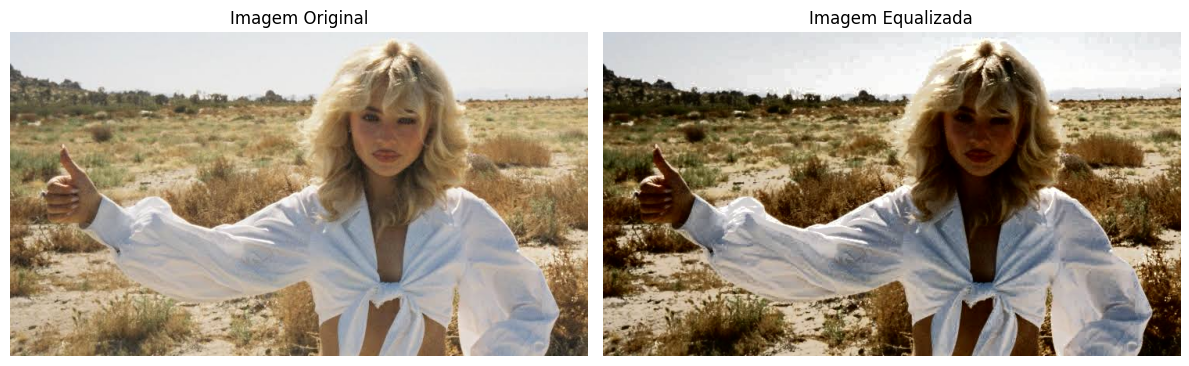

In [90]:
#exibindo a imagem colorida equalizada
fig4, (ax5, ax6) = plt.subplots(1, 2, figsize=(12, 4))

ax5.set_title("Imagem Original")
ax5.imshow(img_color_rgb)
ax5.axis('off')


ax6.set_title("Imagem Equalizada")
ax6.imshow(equ_resultado_rgb)
ax6.axis('off')

fig4.tight_layout()


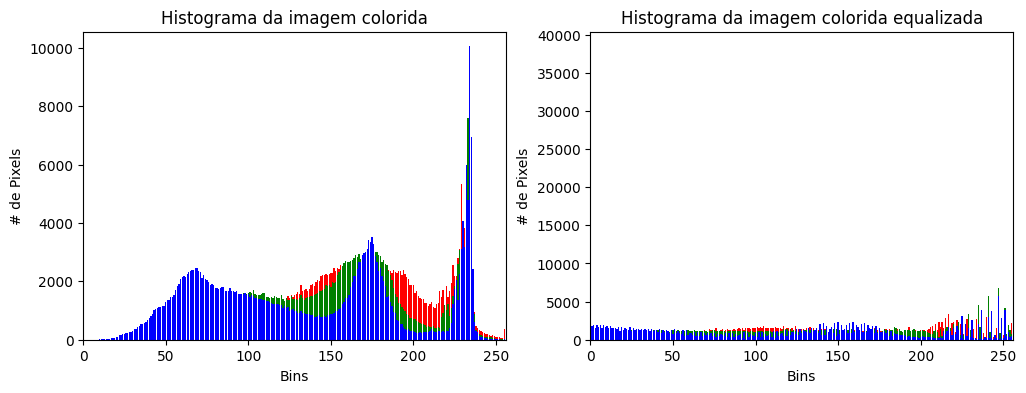

In [97]:
#separando os canais da imagem
#como eu converti para rgb a ordem será red, green, blue
chans2 = cv2.split(equ_resultado_rgb)

fig8, (ax13, ax14) = plt.subplots(1, 2, figsize=(12, 4))

#plotando o histograma da imagem colorida
ax13.set_title("Histograma da imagem colorida")
ax13.set_xlabel("Bins")
ax13.set_ylabel("# de Pixels")

#plotando o histograma da imagem colorida equalizada
ax14.set_title("Histograma da imagem colorida equalizada")
ax14.set_xlabel("Bins")
ax14.set_ylabel("# de Pixels")

#loop para os canais da imagem original
for (chan, color) in zip(chans, colors):
  hist = cv2.calcHist([chan], [0], None, [256], [0, 256])
  ax13.bar(range(256), hist.flatten(), color=color)
  ax13.set_xlim([0, 256])

#loop para os canais da imagem equalizada
for (chan, color) in zip(chans2, colors):
  hist2 = cv2.calcHist([chan], [0], None, [256], [0, 256])
  ax14.bar(range(256), hist2.flatten(), color=color)
  ax14.set_xlim([0, 256])

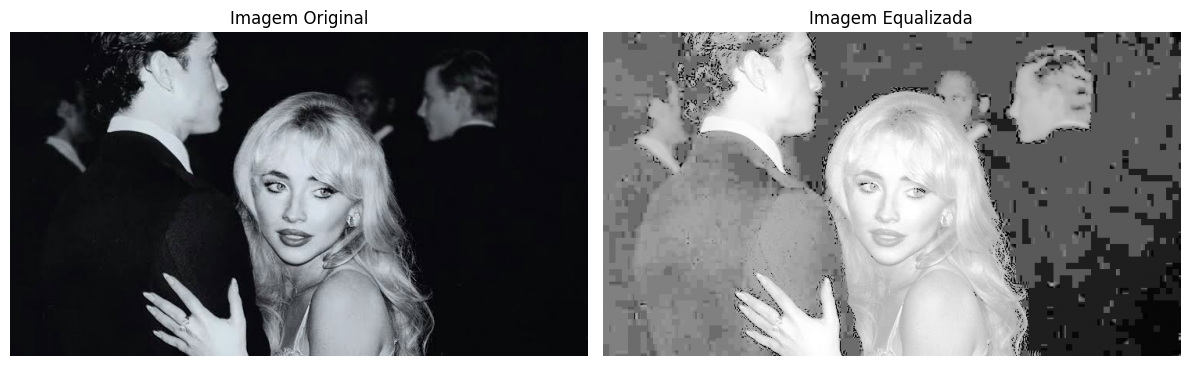

In [91]:
from google.colab.patches import cv2_imshow
#exibindo a imagem preto e branco equalizada
#cv2_imshow(equ)  #para usar o proprio opencv

fig5, (ax7, ax8) = plt.subplots(1, 2, figsize=(12, 4))

ax7.set_title("Imagem Original")
ax7.imshow(img_black_white)
ax7.axis('off')

ax8.set_title("Imagem Equalizada")
ax8.imshow(equ, cmap='gray')
ax8.axis('off')

fig5.tight_layout()

Observa-se na equalização da imagem preto e branco ocorreu um problema, **o fundo está granulado**, isso ocorre **porque a equalização realizada foi global** (utilizou o equalizeHist) e esse tipo analisa o histograma da imagem de uma vez só e redistribui as frequências de cinza para cobrir toda a faixa de 0 a 255. Por conseguinte, uma imagem com o fundo escuro (como a que esta sendo trabalhada) tem o tom preto ocupando uma grande porcentagem dos pixels e o ***equalizeHist tenta esticar esses pixels pretos ao longo do espectro, assim gerando os ruídos***.

Para resolver esse problema a equalização utilizada deveria ter sido a adaptativa, pois se ajusta conforme as características locais de cada região da imagem. Uma das ténicas adaptativas é **CLAHE** (*Constrast Limited Adaptive Histogram Equalization*), que é utilizada para melhorar o contraste local.

***O que o CLAHE executa?***

Ele divide a imagem em uma grade de pequenos blocos (8x8) e o constraste é equalizado de forma independente em cada região. Ademais, também existe um teto máximo para a redistribuição de contraste (geralmente clipLimit=2.0), dessa maneira se uma determinada tonalidade aparecer demais em um dos blocos o algoritmo corta o excesso de contraste e distribui suavemente em outros tons.

In [92]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_clahe = clahe.apply(gray_img)

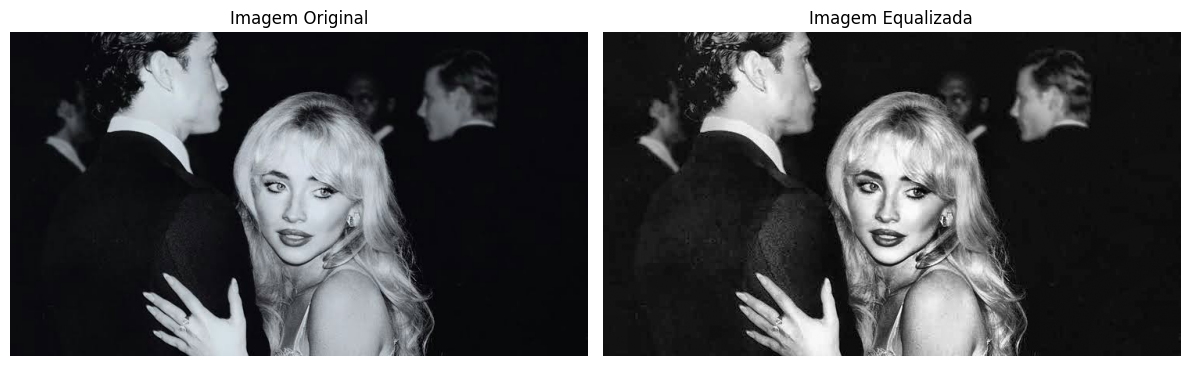

In [93]:
from google.colab.patches import cv2_imshow
#exibindo a imagem preto e branco equalizada
#cv2_imshow(equ)  #para usar o proprio opencv

fig6, (ax9, ax10) = plt.subplots(1, 2, figsize=(12, 4))

ax9.set_title("Imagem Original")
ax9.imshow(img_black_white)
ax9.axis('off')

ax10.set_title("Imagem Equalizada")
ax10.imshow(img_clahe, cmap='gray')
ax10.axis('off')

fig6.tight_layout()

(0.0, 256.0)

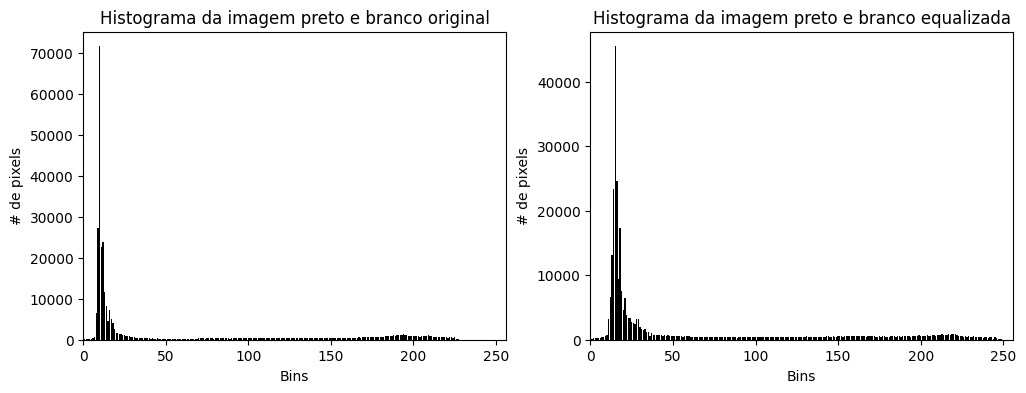

In [94]:
#calculando o histograma das imagens preto e branco
hist_black_white_equ = cv2.calcHist([img_clahe], [0], None, [256], [0, 256])

fig7, (ax11, ax12) = plt.subplots(1, 2, figsize=(12, 4))

#plotando o histograma da imagem original
ax11.set_title("Histograma da imagem preto e branco original")
ax11.set_xlabel("Bins")
ax11.set_ylabel("# de pixels")
ax11.bar(range(256), hist_black_white.flatten(), color='black')
ax11.set_xlim([0, 256])

#plotando o histograma da imagem equalizada
ax12.set_title("Histograma da imagem preto e branco equalizada")
ax12.set_xlabel("Bins")
ax12.set_ylabel("# de pixels")
ax12.bar(range(256), hist_black_white_equ.flatten(), color='black')
ax12.set_xlim([0, 256])

*Referências*


---


[OpenCV Image Histograms (cv2.calcHist)](https://pyimagesearch.com/2021/04/28/opencv-image-histograms-cv2-calchist/)


---


[Explorando Histogramas 2D em Python com Plotly](https://hub.asimov.academy/tutorial/explorando-histogramas-2d-em-python-com-plotly/)


---

[A Tutorial to Histogram Equalization](https://medium.com/@kyawsawhtoon/a-tutorial-to-histogram-equalization-497600f270e2)